In [2]:
import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from prettytable import PrettyTable
from tqdm.auto import tqdm

from cultural_utils import *

## Fig 5 (b)

In [3]:
# pth = '/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_cultural/Qwen2.5-VL-72B-Instruct/pd_annotations.pkl'
pth = '/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_cultural/gemini/pd_annotations.pkl'

df = pd.read_pickle(pth)
df.columns

Index(['clip', 'clip_index', 'frame', 'dataset', 'density', 'city', 'country',
       'num_groups', 'activity', 'clothing', 'handholding',
       'handholding_binary', 'hugging', 'hugging_binary', 'file', 'video',
       'globe_region'],
      dtype='object')

In [4]:
act_df = df.groupby('globe_region').agg({'activity': list}).reset_index()
act_df['activity'] = act_df['activity'].apply(lambda x: merge_list(x))
act_df['activity_counts'] = act_df['activity'].apply(lambda x: Counter([item for item in x]))

In [5]:
#print top 9 activities for each region
for idx, row in act_df.iterrows():
    print(f"{row['globe_region']}")
    for activity, count in row['activity_counts'].most_common(9):
        print(f"{activity}: {count}")
    print()

African
standing: 78
walking: 71
watching: 29
waiting: 16
gathering: 13
standing in a crowd: 10
attending an event: 10
watching a performance: 9
driving: 9

Anglo
walking: 910
standing: 438
sitting: 121
socializing: 78
waiting: 67
watching: 66
sightseeing: 59
talking: 59
cosplaying: 46

Confucian Asia
walking: 541
standing: 246
waiting: 66
crossing the street: 53
shopping: 43
holding umbrella: 39
strolling: 36
sightseeing: 34
sitting: 33

Eastern Europe
walking: 152
standing: 36
sitting: 27
talking: 14
resting: 7
strolling: 7
sightseeing: 7
pointing: 6
holding hands: 5

Germanic Europe
walking: 106
sitting: 77
standing: 40
watching: 16
resting: 13
relaxing: 9
socializing: 8
strolling: 7
observing: 7

Latin America
walking: 59
standing: 28
sitting: 19
waiting: 7
driving: 7
shopping: 6
watching: 4
talking: 4
holding hands: 4

Latin Europe
standing: 144
walking: 125
swimming: 58
sitting: 57
sightseeing: 44
watching: 37
dining: 33
shopping: 18
socializing: 18

Middle East
walking: 190
stan

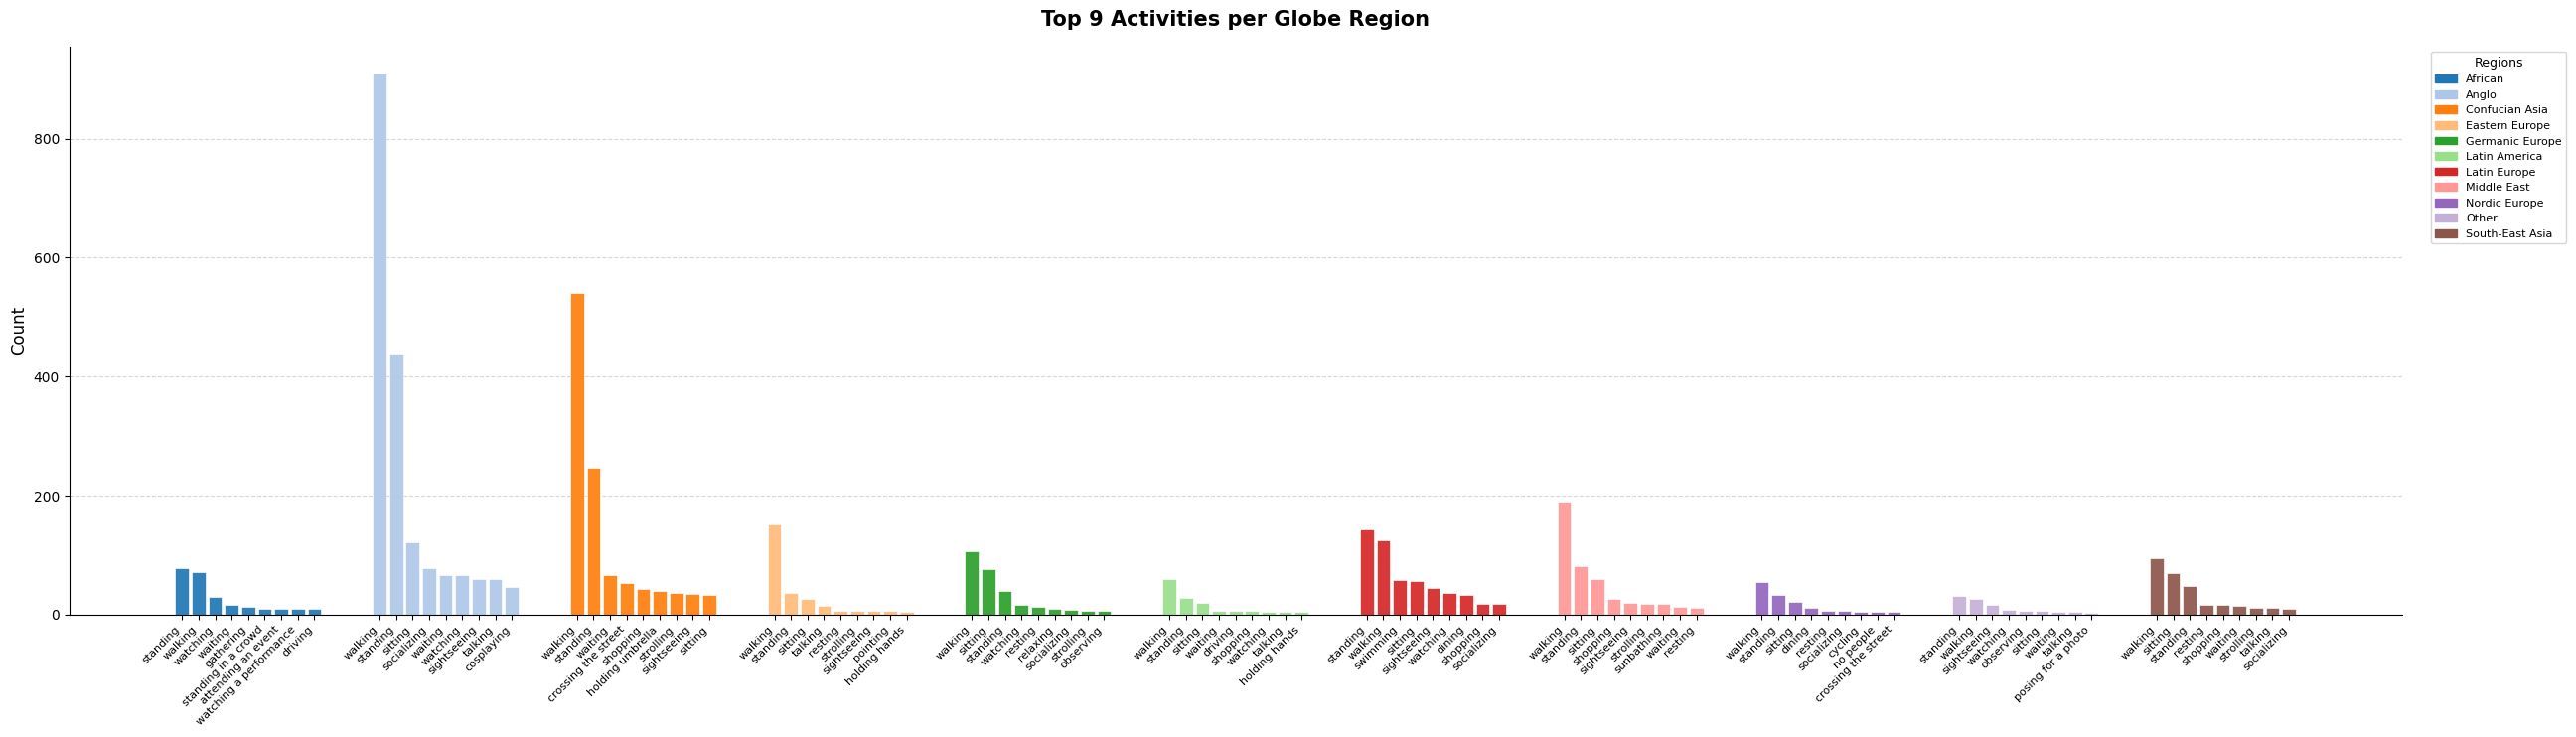

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

# --- Example: replace df with your actual dataframe ---
# df has columns: 'region' and 'activity_counts' (Counter objects)

def plot_region_activities(df, region_col='region', counts_col='activity_counts', top_n=9):
    regions = df[region_col].tolist()
    
    # Color palette - one color per region
    colors = plt.cm.tab20.colors
    
    fig, ax = plt.subplots(figsize=(26, 8))
    
    x_pos = 0
    x_ticks = []
    x_labels = []
    legend_patches = []
    region_centers = []
    group_gap = 2.5   # gap between region groups
    bar_width = 0.7
    bar_gap = 0.15    # gap between bars within a region
    
    for i, row in df.iterrows():
        region = row[region_col]
        counter = row[counts_col]
        color = colors[i % len(colors)]
        
        # Get top N activities
        top_items = counter.most_common(top_n)
        if not top_items:
            continue
        
        activities, counts = zip(*top_items)
        group_start = x_pos
        
        for j, (activity, count) in enumerate(zip(activities, counts)):
            ax.bar(x_pos, count, width=bar_width, color=color, 
                   edgecolor='white', linewidth=0.5, alpha=0.92)
            x_ticks.append(x_pos)
            x_labels.append(activity)
            x_pos += bar_width + bar_gap
        
        # Center label for the region
        group_center = (group_start + x_pos - bar_width - bar_gap) / 2
        region_centers.append((group_center, region))
        
        legend_patches.append(mpatches.Patch(color=color, label=region))
        x_pos += group_gap  # space between regions
    
    # X-axis activity labels
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    
    # Add region name annotations below the activity labels
    y_min = ax.get_ylim()[0]
    # for center, name in region_centers:
    #     ax.annotate(name, xy=(center, y_min), xytext=(0, -55),
    #                 textcoords='offset points', ha='center', fontsize=8.5,
    #                 fontweight='bold', color='#333333',
    #                 annotation_clip=False)
    
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Top 9 Activities per Globe Region', fontsize=15, fontweight='bold', pad=15)
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1), loc='upper left', 
              fontsize=8, title='Regions', title_fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)
    plt.savefig('region_activities.png', dpi=150, bbox_inches='tight')
    plt.show()

# Call it:
plot_region_activities(act_df, 'globe_region')

In [ ]:
# # use nltk to remove stop words and punctuation from the activity list and then print top 9 activities for each region
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize
# import string

# stop_words = set(stopwords.words('english'))
# punctuation = set(string.punctuation)

# for idx, row in act_df.iterrows():
#     print(f"Region: {row['globe_region']}")
#     activity_list = row['activity']
#     filtered_activities = []
#     for activity in activity_list:
#         tokens = word_tokenize(activity)
#         filtered_tokens = [word for word in tokens if word.lower() not in stop_words and word not in punctuation]
#         filtered_activities.append(' '.join(filtered_tokens))
#     activity_counts = Counter(filtered_activities)
#     for activity, count in activity_counts.most_common(12):
#         print(f"{activity}: {count}")
#     print("\n")

Region: African
walking: 53
waiting: 36
waiting line: 20
socializing: 18
conversing: 16
watching performance: 14
attending event: 14
observing: 9
standing: 7
resting: 7
shopping: 6
queuing: 6


Region: Anglo
walking: 650
socializing: 273
waiting: 127
observing: 126
sightseeing: 95
waiting line: 92
conversing: 91
shopping: 79
dining: 65
talking: 49
walking rain: 48
cosplaying: 47


Region: Confucian Asia
walking: 416
waiting: 102
socializing: 97
observing: 68
shopping: 58
crossing street: 44
conversing: 42
sightseeing: 42
walking rain: 39
waiting line: 39
talking: 25
resting: 23


Region: Eastern Europe
walking: 146
socializing: 26
sightseeing: 23
conversing: 17
resting: 15
observing: 11
strolling: 9
shopping: 7
standing: 7
talking: 5
waiting: 4
sitting: 4


Region: Germanic Europe
walking: 94
socializing: 58
relaxing: 22
observing: 18
talking: 18
conversing: 15
resting: 15
waiting: 14
sightseeing: 11
sitting: 10
shopping: 10
watching: 6


Region: Latin America
walking: 58
socializing: 

## Fig 6

In [6]:
pth1 = '/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_cultural/Qwen2.5-VL-72B-Instruct/pd_annotations.pkl'
pth2 = '/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_cultural/Qwen3-VL-30B-A3B-Instruct/pd_annotations.pkl'
pth3 = '/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_cultural/deepseek-vl2/pd_annotations.pkl'
pth4 = '/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_cultural/llava-v1.6-mistral-7b-hf/pd_annotations.pkl'
pth5 = '/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_cultural/gemini/pd_annotations.pkl'

df1 = pd.read_pickle(pth1)
df2 = pd.read_pickle(pth2)
df3 = pd.read_pickle(pth3)
df4 = pd.read_pickle(pth4)
df5 = pd.read_pickle(pth5)

In [7]:
def get_activity_counts(df):
    act_df = df.groupby('globe_region').agg({'activity': list}).reset_index()
    act_df['activity'] = act_df['activity'].apply(lambda x: merge_list(x))
    act_df['activity_counts'] = act_df['activity'].apply(lambda x: Counter([item for item in x]))
    return act_df

In [8]:
act_df1 = get_activity_counts(df1)
act_df2 = get_activity_counts(df2)
act_df3 = get_activity_counts(df3)
act_df4 = get_activity_counts(df4)
act_df5 = get_activity_counts(df5)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

def plot_region_by_model(dataframes, model_names, region, region_col='region',
                          counts_col='activity_counts', top_n=9):
    """
    dataframes  : list of 5 DataFrames, each with region_col and counts_col
    model_names : list of 5 label strings e.g. ['Model A', 'Model B', ...]
    region      : string matching a value in region_col
    """
    colors = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#9B5DE5']
    bar_width = 0.7
    bar_gap = 0.15
    group_gap = 2.5

    fig, ax = plt.subplots(figsize=(26, 8))

    x_pos = 0
    x_ticks = []
    x_labels = []
    legend_patches = []

    for m_idx, (df, name, color) in enumerate(zip(dataframes, model_names, colors)):
        row = df[df[region_col] == region]
        if row.empty:
            continue

        counter = row.iloc[0][counts_col]
        top_items = counter.most_common(top_n)
        if not top_items:
            continue

        activities, counts = zip(*top_items)

        for activity, count in zip(activities, counts):
            ax.bar(x_pos, count, width=bar_width, color=color,
                   edgecolor='white', linewidth=0.5, alpha=0.92)
            x_ticks.append(x_pos)
            x_labels.append(activity)
            x_pos += bar_width + bar_gap

        legend_patches.append(mpatches.Patch(color=color, label=name))
        x_pos += group_gap  # space between model groups

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Top {top_n} Activities per Model — {region}', fontsize=14, fontweight='bold', pad=15)
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1), loc='upper left',
              fontsize=9, title='Model', title_fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(f'activities_{region.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [21]:
act_df4.loc[act_df4['globe_region'] == 'South-East Asia', 'activity_counts'].values[0].most_common(9)

[('shopping', 85),
 ('socializing', 81),
 ('walking', 31),
 ('social gathering', 28),
 ('commuting', 15),
 ('sightseeing', 13),
 ('eating', 11),
 ('waiting', 10),
 ('exploring', 7)]

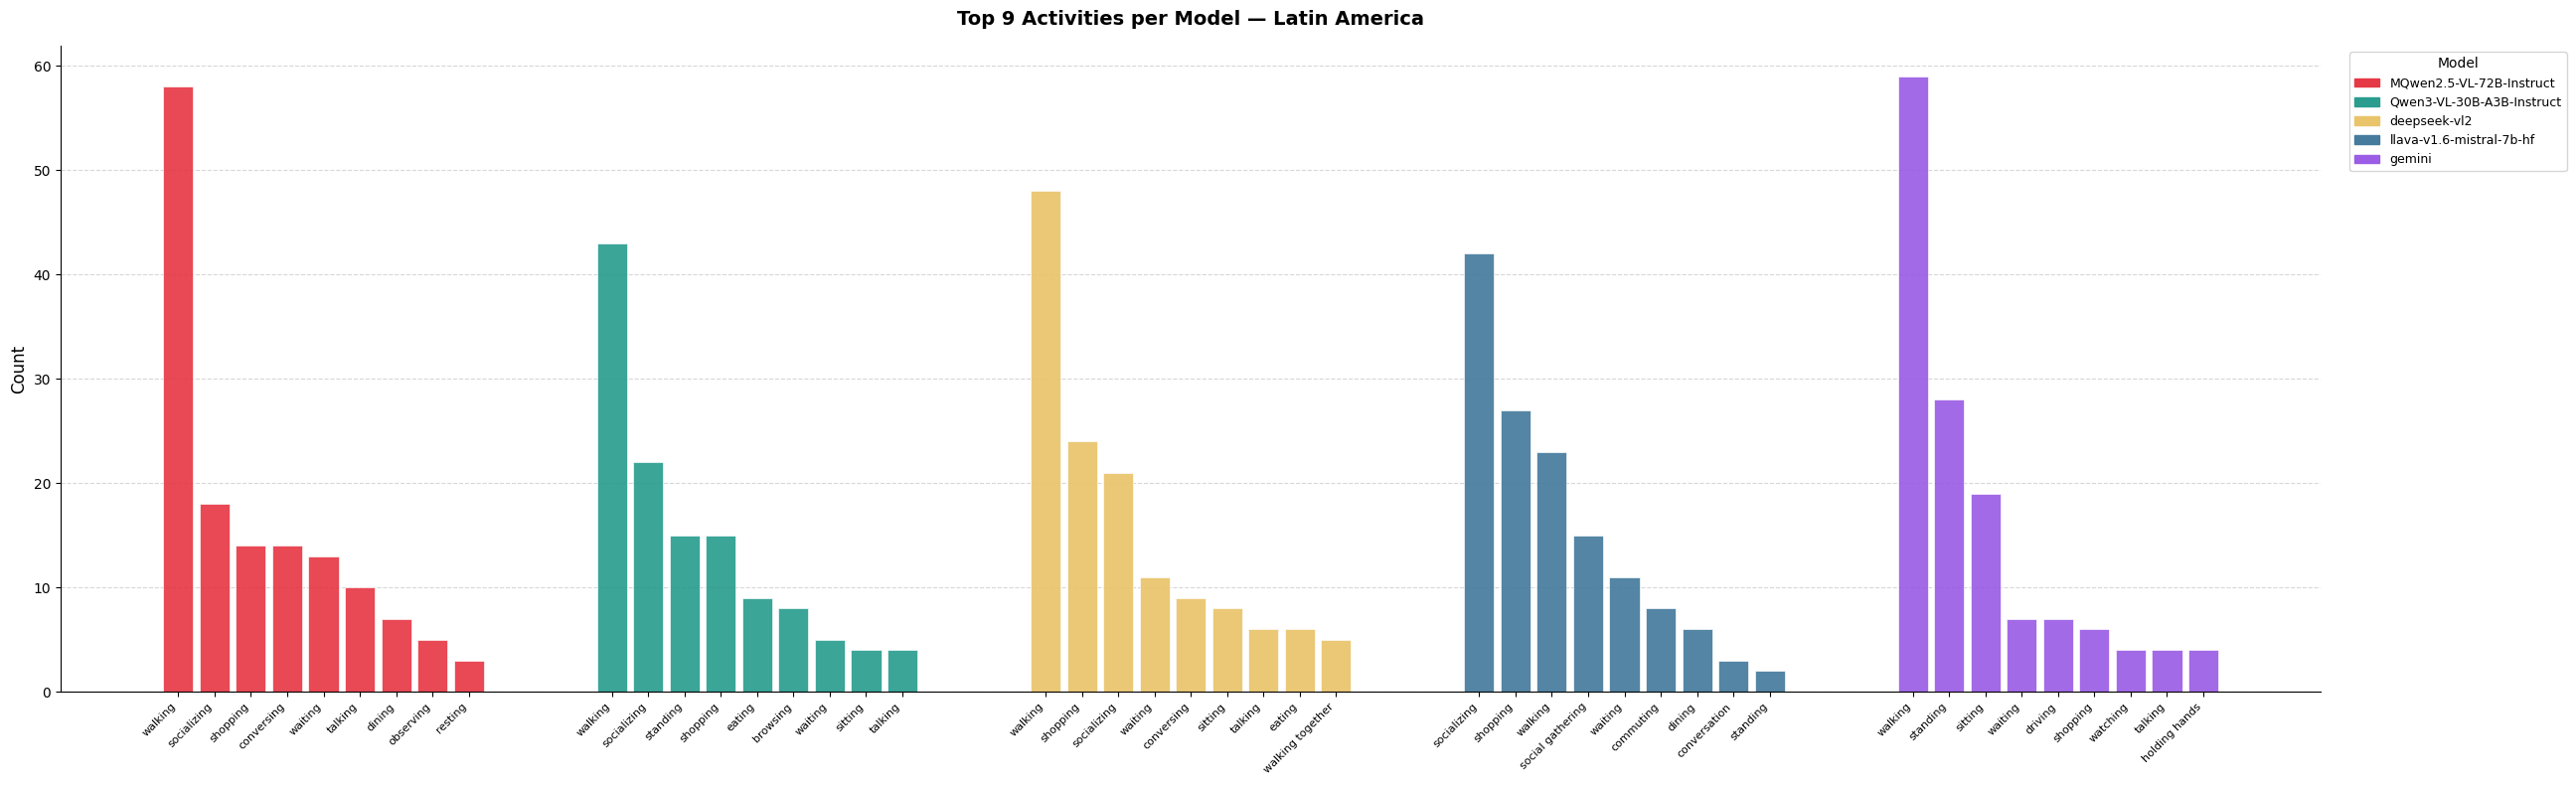

In [12]:
# Usage:
plot_region_by_model(
    dataframes=[act_df1, act_df2, act_df3, act_df4, act_df5],
    model_names=['MQwen2.5-VL-72B-Instruct', 'Qwen3-VL-30B-A3B-Instruct', 'deepseek-vl2', 'llava-v1.6-mistral-7b-hf', 'gemini'],
    region='Latin America',
    region_col='globe_region',
    counts_col='activity_counts',
)

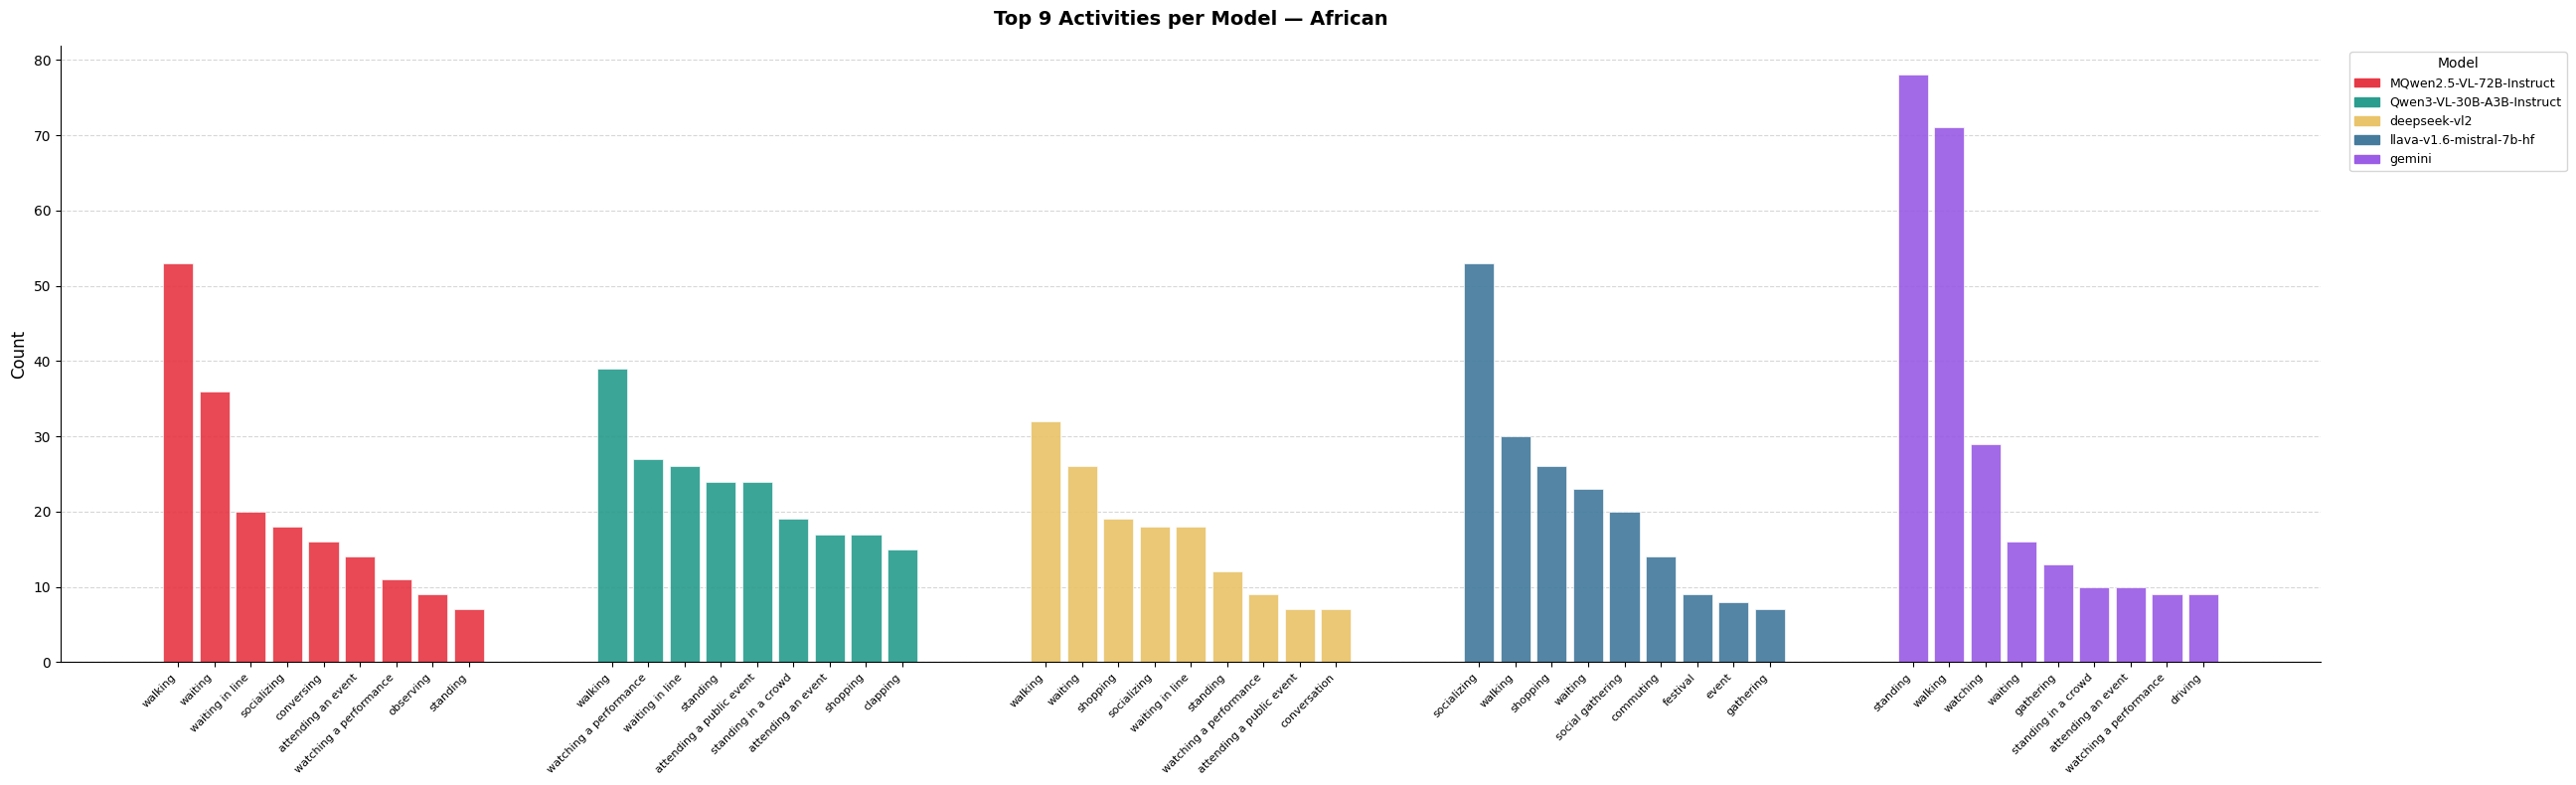

In [13]:
# Usage:
plot_region_by_model(
    dataframes=[act_df1, act_df2, act_df3, act_df4, act_df5],
    model_names=['MQwen2.5-VL-72B-Instruct', 'Qwen3-VL-30B-A3B-Instruct', 'deepseek-vl2', 'llava-v1.6-mistral-7b-hf', 'gemini'],
    region='African',
    region_col='globe_region',
    counts_col='activity_counts',
)

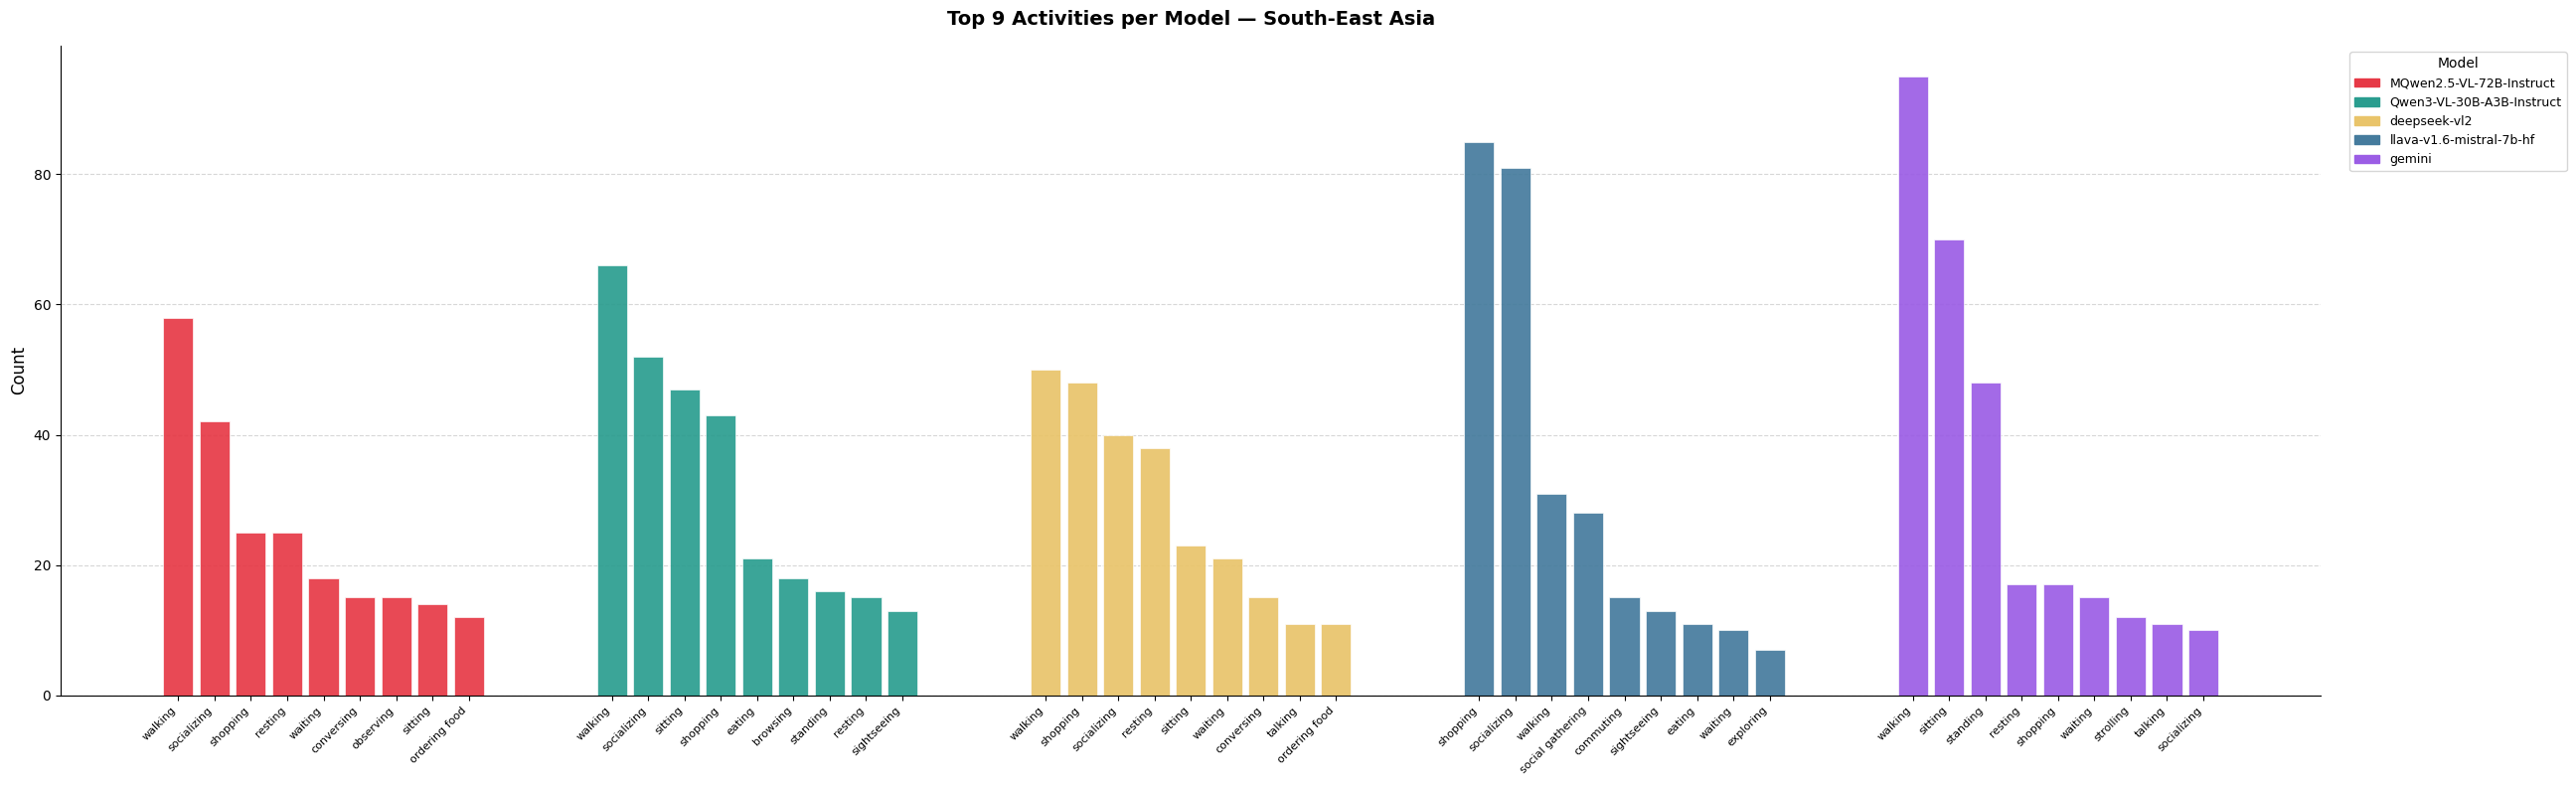

In [14]:
# Usage:
plot_region_by_model(
    dataframes=[act_df1, act_df2, act_df3, act_df4, act_df5],
    model_names=['MQwen2.5-VL-72B-Instruct', 'Qwen3-VL-30B-A3B-Instruct', 'deepseek-vl2', 'llava-v1.6-mistral-7b-hf', 'gemini'],
    region='South-East Asia',
    region_col='globe_region',
    counts_col='activity_counts',
)